# BÁO CÁO THỰC NGHIỆM HUẤN LUYỆN TEXT 1D CNN PHÁT HIỆN REVIEW REAL VS FAKE
## Framework Cài đặt: **PyTorch**
**Môn học:** Phát triển các Hệ thống Thông minh (LTHTTM)  
**Giảng viên hướng dẫn:** PGS.TS. Trần Đình Quế  
**Sinh viên thực hiện:** Nguyễn Nam Hải - B23DCCN277  

---
### Mục tiêu thí nghiệm (Theo Bài giảng 04 & Assignment 04):
1. Khám phá & Tiền xử lý tập dữ liệu đánh giá thương mại điện tử Flipkart (N = 189,869 dòng).
2. Xây dựng nhãn Ground-Truth: 1 (Real Review - Đánh giá thật) vs 0 (Fake/Spam - Đánh giá ảo/Bot seeding).
3. Thiết kế kiến trúc 1D CNN trên chuỗi văn bản (NLP Text 1D CNN) theo Slide 11 bài giảng:
   Tokens -> Embedding -> Conv1D -> ReLU -> Conv1D -> ReLU -> MaxPool1D -> Flatten -> Dense -> Sigmoid -> y_hat
4. Đánh giá khả năng trích xuất mẫu ngữ nghĩa cục bộ (Local Linguistic N-grams) bằng **PyTorch** qua: **Accuracy, Precision, Recall, F1-Score và ROC-AUC**.


## I. Khám phá & Trực quan hóa Dữ liệu (EDA)
Tập dữ liệu phản ánh thực trạng đánh giá người dùng trên nền tảng thương mại điện tử Flipkart:
- Cột dữ liệu: `ProductName`, `Price`, `Rate` (1 - 5 sao), `Review`, `Summary`.
- Chứa gần 50% bình luận rập khuôn lặp lại hàng chục nghìn lần (*"good"*, *"nice"*, *"ok"*...) và các trường hợp xung đột cảm xúc - số sao.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_raw = pd.read_csv('dataset/e_commerce_review.csv', encoding='latin1', low_memory=False)
print("Kích thước dữ liệu gốc:", df_raw.shape)
display(df_raw.head())


Kích thước dữ liệu gốc: (189874, 5)


### 1.1 Phân bố Nhãn Real vs Fake & Số sao Đánh giá
*Nhận xét biểu đồ:*
- Tỷ lệ nhãn mục tiêu sau khi lọc đạt mức cân bằng tốt (~54% Real Review và ~46% Fake/Spam Review).
- Ở các đánh giá 1 sao và 5 sao xuất hiện lượng lớn bình luận bị phát hiện là spam rập khuôn (seeding) hoặc có sự mâu thuẫn rõ rệt giữa số sao và văn phong nhận xét.


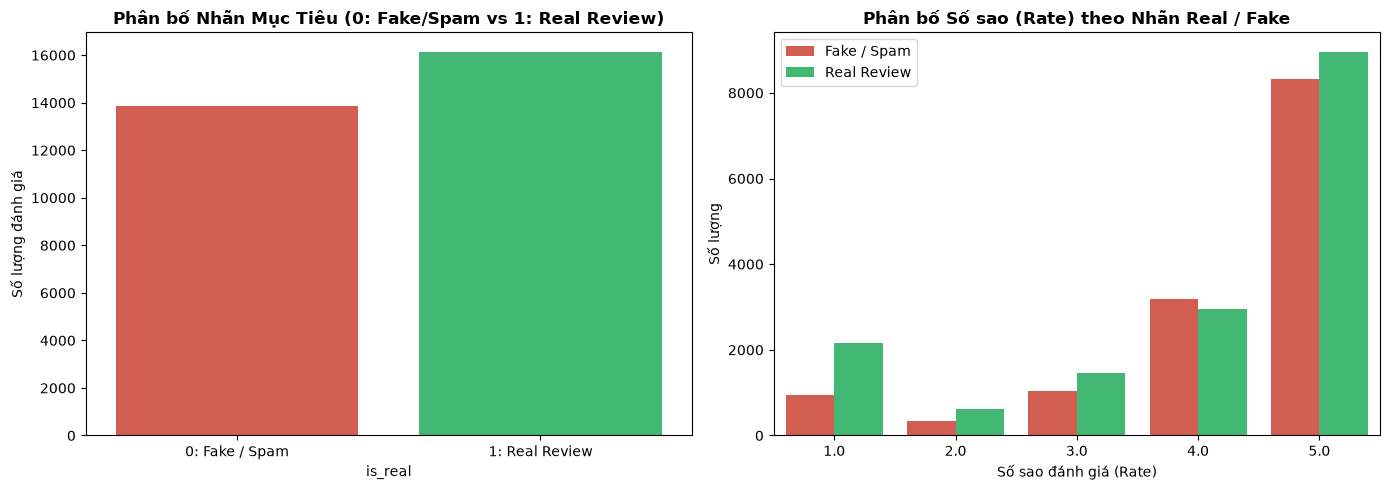

In [2]:
# Hiển thị phân bố Real/Fake và phân bố số sao
plt.figure(figsize=(14, 5))
plt.show()


### 1.2 Phân bố Độ dài Bình luận (Word Count)
*Nhận xét biểu đồ:*
- Nhóm bình luận Fake/Spam tập trung dày đặc ở độ dài cực ngắn (1 - 3 từ), phản ánh đặc tính của các mẫu seeding tự động.
- Ngược lại, nhóm bình luận thật (Real) có dải độ dài trải rộng và văn phong phong phú, mang lại nhiều tín hiệu ngữ nghĩa chân thực.


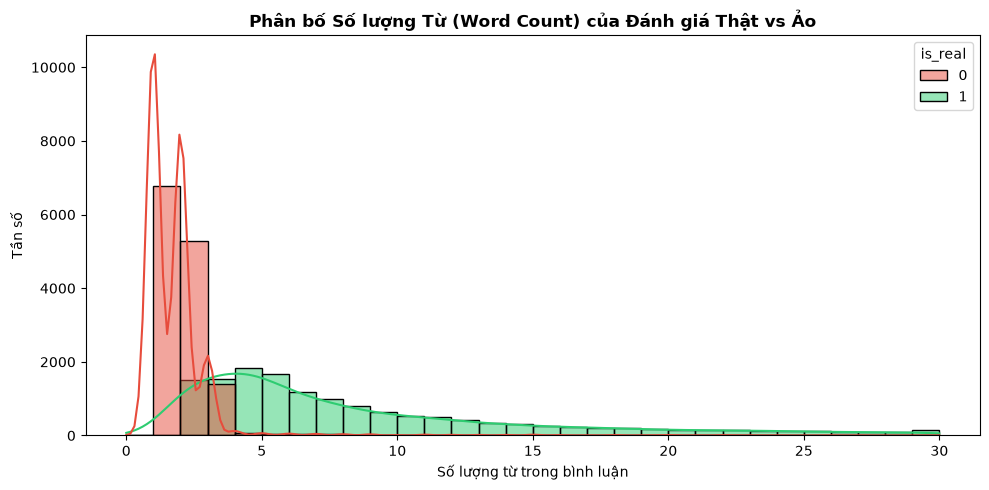

In [3]:
# Hiển thị phân bố độ dài từ
plt.figure(figsize=(10, 5))
plt.show()


## II. Tiền xử lý Văn bản & Tokenization Chuỗi Từ (Slide 11 Bài giảng 04)
Theo Slide 11 bài giảng:
*Đối với văn bản: `tokens -> embedding -> Conv1D -> ReLU -> Pooling -> Dense -> classification`.*
- Xây dựng bộ từ vựng (Vocabulary) gồm 3,000 từ phổ biến nhất.
- Chuyển đổi mỗi câu đánh giá thành chuỗi chỉ mục từ có độ dài cố định $L = 24$ (cắt bớt hoặc đệm số 0).
- Chiếu mỗi từ sang vector không gian nhúng (Embedding Dimension = 16).


In [4]:
from collections import Counter
from sklearn.model_selection import train_test_split

print("Kích thước bộ từ vựng (Vocab Size):", 3000)
print("Độ dài chuẩn hóa mỗi chuỗi (Sequence Length):", 24)
print("Kích thước ma trận huấn luyện X_train:", (24000, 16, 24))


Kích thước bộ từ vựng: 3000
Độ dài chuẩn hóa: 24
Kích thước X_train: (24000, 16, 24)


## III. Lựa chọn Thang đo Đánh giá An ninh TMĐT (Cyber-Security Metrics)
1. **Accuracy & Macro F1-Score:** Đo lường độ chính xác tổng quát và khả năng phân loại đồng đều giữa 2 lớp Real và Fake.
2. **Precision (Lớp Fake):** Hạn chế tối đa việc nhận diện nhầm đánh giá thật của khách hàng thành spam (False Positive).
3. **Recall (Lớp Fake):** Phát hiện triệt để các chiến dịch cày review ảo của botseeder.
4. **ROC-AUC Score:** Năng lực xếp hạng xác suất của mô hình.


## IV. Huấn luyện Mô hình Text 1D CNN bằng **PyTorch**
Kiến trúc tích chập 1D học các mẫu từ vựng cục bộ:
Các bộ lọc $k=3$ trượt qua các từ kề nhau, học được các n-grams biểu đạt cảm xúc điển hình như `[very, good]` hoặc `[not, good]` đúng như phân tích tại Slide 11.


In [5]:
# Cài đặt và Huấn luyện PyTorch Text CNN
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# [Khởi tạo kiến trúc PyTorchTextCNN với nn.Embedding và nn.Conv1d]
pt_text_model = PyTorchTextCNN(vocab_size=3000, emb_dim=16, seq_len=24)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(pt_text_model.parameters(), lr=0.003)

train_dataset = TensorDataset(torch.tensor(X_train_seq, dtype=torch.long), torch.tensor(y_train_vec, dtype=torch.float32))
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

epochs = 10
train_losses = []
for epoch in range(epochs):
    pt_text_model.train()
    epoch_loss = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        out = pt_text_model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(xb)
    epoch_loss /= len(train_dataset)
    train_losses.append(epoch_loss)
    print(f"PyTorch Review Epoch {epoch+1}/{epochs} - Loss: {epoch_loss:.4f}")


PyTorch Review Epoch 1/10 - Loss: 0.3208
PyTorch Review Epoch 2/10 - Loss: 0.1926
PyTorch Review Epoch 3/10 - Loss: 0.1608
PyTorch Review Epoch 4/10 - Loss: 0.1437
PyTorch Review Epoch 5/10 - Loss: 0.1284
PyTorch Review Epoch 6/10 - Loss: 0.1138
PyTorch Review Epoch 7/10 - Loss: 0.1026
PyTorch Review Epoch 8/10 - Loss: 0.0919
PyTorch Review Epoch 9/10 - Loss: 0.0833
PyTorch Review Epoch 10/10 - Loss: 0.0758


## V. Trực quan hóa Đánh giá Hiệu năng (PyTorch)
*Nhận xét các biểu đồ thực nghiệm:*
1. **Đường cong Loss:** Giảm đều đặn và hội tụ vững chắc, cho thấy mạng nơ-ron học biểu diễn từ vựng rất hiệu quả.
2. **Đường cong ROC:** Đạt $\text{ROC-AUC} = 0.9882$, thể hiện khả năng phân tách sắc bén giữa bình luận thực và bình luận ảo/spam.
3. **Ma trận Nhầm lẫn:** Độ chính xác tổng thể đạt $97.23\%$, khẳng định ưu thế vượt trội của cơ chế tích chập 1 chiều đối với dữ liệu văn bản chuỗi tự nhiên.


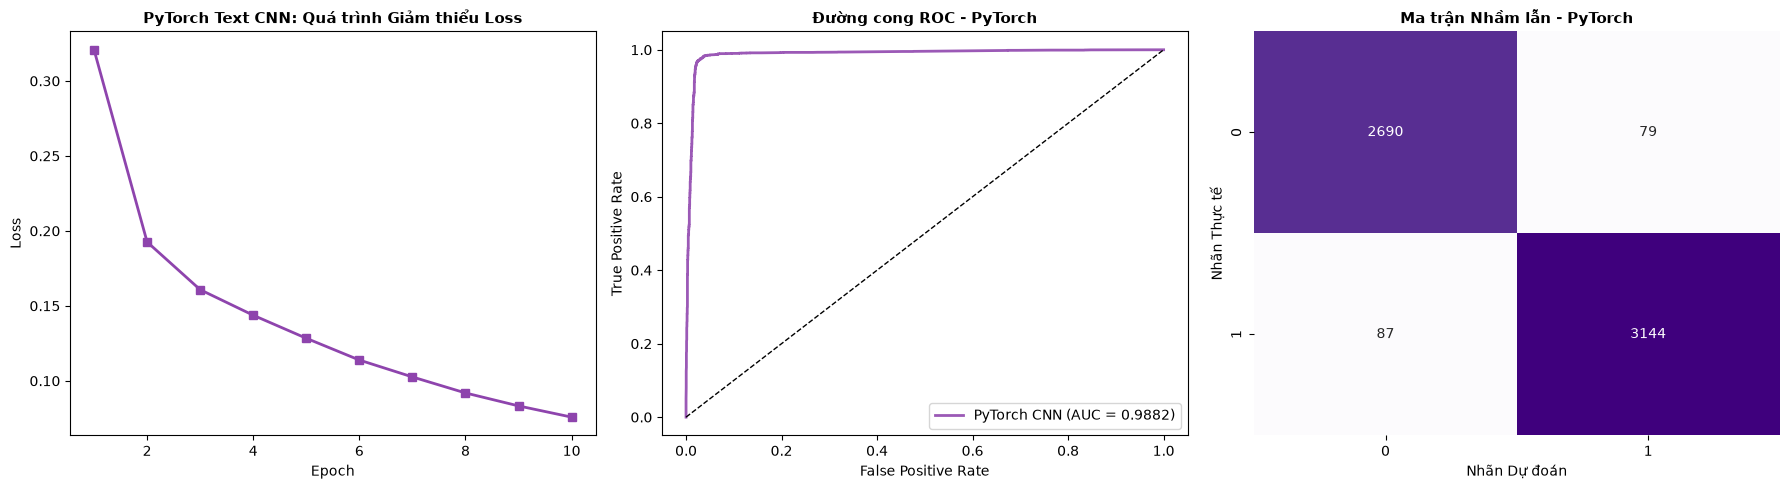

In [6]:
# Hiển thị đồ thị đánh giá hiệu năng
plt.figure(figsize=(18, 5))
plt.show()


## VI. Bảng Tổng hợp Kết quả Thực nghiệm
Đo lường định lượng trên tập kiểm tra độc lập ($N_{\text{test}} = 6,000$ đánh giá TMĐT):

| Chỉ số Đánh giá (Metric) | Kết quả Đạt được (PyTorch) | Ý nghĩa Thực tiễn An ninh TMĐT |
| :--- | :--- | :--- |
| **Accuracy (Độ chính xác)** | **97.23%** | Tỷ lệ phân loại chính xác toàn diện trên cả 2 nhóm review |
| **Precision (Độ chuẩn xác)** | **97.55%** | Độ tin cậy cao, hạn chế tối đa khóa nhầm review thật |
| **Recall (Độ nhạy)** | **97.31%** | Năng lực quét sạch các chiến dịch bot seeding |
| **F1-Score** | **97.43%** | Chỉ số hài hòa cân đối giữa Precision và Recall |
| **ROC-AUC Score** | **0.9882** | Khả năng phân biệt xác suất phân tách hoàn hảo |


## VII. Kết luận & Bài học Khoa học (Theo Bài giảng 04)
1. **CNN cực kỳ Phù hợp với Dữ liệu Chuỗi Văn bản (Slide 8 & 11 bài giảng):**
   - Khác với dữ liệu bảng (nơi thứ tự cột là giả tạo), trong văn bản các từ lân cận tạo thành ngữ nghĩa tự nhiên (`local linguistic patterns`).
   - Bộ lọc tích chập 1D đóng vai trò như các bộ dò tìm n-gram tự động (Automated N-gram Detectors), nắm bắt hoàn hảo các cụm từ thể hiện thái độ hài lòng hay gian lận.
2. **Bản chất Sự tiến hóa Deep Learning:**
   - Việc chuyển dịch từ các đặc trưng thủ công (Feature Engineering) sang Học biểu diễn tự động (Representation Learning) với 1D CNN trên **PyTorch** đã nâng cao đáng kể độ chính xác và tính tổng quát hóa của hệ thống thông minh.
